# CNN

In [ ]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from src.data.dataloader import get_dataloaders
from models.cnn_improved import ImprovedCNN
from src.training.trainer import train_one_epoch, validate_one_epoch

In [3]:
use_mps = True
print("MPS available:", torch.backends.mps.is_available())
device = torch.device("mps" if (use_mps and torch.backends.mps.is_available()) else "cpu")
print(f"Using device: {device}")

MPS available: True
Using device: mps


In [ ]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv="../data/splits/train.csv",
    val_csv="../data/splits/val.csv",
    test_csv="../data/splits/test.csv",
    image_dir="../data/raw/HAM10000/images",
    batch_size=32,
    image_size=224,
    num_workers=0,
)

train_df = pd.read_csv("../data/splits/train.csv")

num_neg = (train_df["label"] == 0).sum()   # nevus
num_pos = (train_df["label"] == 1).sum()   # melanoma

pos_weight = torch.tensor([num_neg / num_pos], dtype=torch.float32).to(device)

print("Positive weight:", pos_weight)

model = ImprovedCNN().to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

Positive weight: tensor([0.1660], device='mps:0')


In [5]:
best_val_loss = float("inf")

num_epochs = 20

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_metrics["loss"])
    val_losses.append(val_metrics["loss"])
    train_accuracies.append(train_metrics["accuracy"])
    val_accuracies.append(val_metrics["accuracy"])

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_metrics['loss']:.4f}, Train Acc: {train_metrics['accuracy']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Val Acc: {val_metrics['accuracy']:.4f}"
    )

    # Save best model
    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        torch.save(model.state_dict(), "../models/cnn_best.pth")
        print("Saved best model at epoch", epoch+1)

Epoch [1/20] | Train Loss: 0.1044, Train Acc: 0.8538 | Val Loss: 0.0933, Val Acc: 0.8576
Saved best model at epoch 1
Epoch [2/20] | Train Loss: 0.0926, Train Acc: 0.8576 | Val Loss: 0.0892, Val Acc: 0.8576
Saved best model at epoch 2
Epoch [3/20] | Train Loss: 0.0902, Train Acc: 0.8576 | Val Loss: 0.0880, Val Acc: 0.8576
Saved best model at epoch 3
Epoch [4/20] | Train Loss: 0.0897, Train Acc: 0.8576 | Val Loss: 0.0896, Val Acc: 0.8576
Epoch [5/20] | Train Loss: 0.0888, Train Acc: 0.8576 | Val Loss: 0.0912, Val Acc: 0.8576
Epoch [6/20] | Train Loss: 0.0874, Train Acc: 0.8576 | Val Loss: 0.0888, Val Acc: 0.8576
Epoch [7/20] | Train Loss: 0.0878, Train Acc: 0.8576 | Val Loss: 0.0868, Val Acc: 0.8576
Saved best model at epoch 7
Epoch [8/20] | Train Loss: 0.0848, Train Acc: 0.8576 | Val Loss: 0.0839, Val Acc: 0.8576
Saved best model at epoch 8
Epoch [9/20] | Train Loss: 0.0845, Train Acc: 0.8576 | Val Loss: 0.0931, Val Acc: 0.8576
Epoch [10/20] | Train Loss: 0.0863, Train Acc: 0.8576 | Val

## Plot Loss and Accuracy Curves

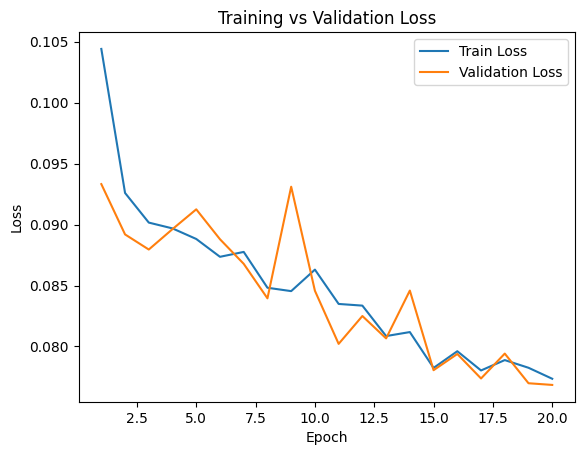

In [6]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

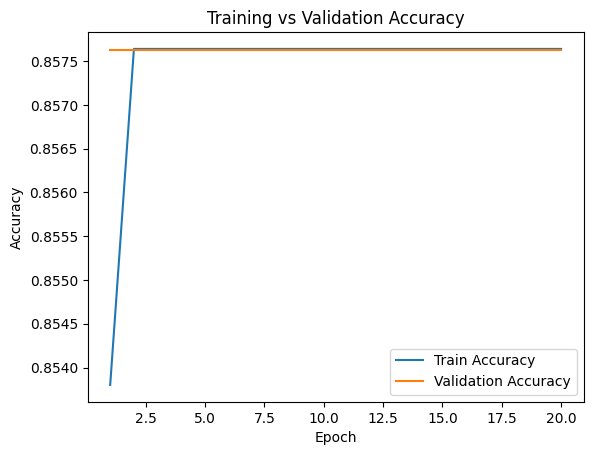

In [7]:
plt.figure()
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

In [8]:
import torch
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

model.eval()

all_labels = []
all_probs = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)                      # raw logits
        probs = torch.sigmoid(outputs).squeeze(1)    # probabilities
        preds = (probs >= 0.1).long()              # binary predictions

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

In [9]:
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[946  60]
 [ 77  90]]


[[TN, FP],<BR/>
 [FN, TP]]

- TN: correctly predicted non-melanoma
- FP: benign predicted as melanoma
- FN: melanoma missed
- TP: correctly predicted melanoma

In [10]:
print(all_probs[:20])

[np.float32(9.3500115e-05), np.float32(0.001540119), np.float32(0.18308331), np.float32(0.0010032323), np.float32(0.30418542), np.float32(0.021325788), np.float32(0.009137274), np.float32(9.860504e-07), np.float32(1.8941542e-05), np.float32(0.0002538791), np.float32(0.018035226), np.float32(0.000162871), np.float32(0.086399436), np.float32(2.5952184e-05), np.float32(0.3760315), np.float32(1.9869185e-05), np.float32(0.094795555), np.float32(4.2694132e-06), np.float32(0.0002496404), np.float32(0.01700006)]


In [11]:
print(classification_report(all_labels, all_preds, digits=4))

              precision    recall  f1-score   support

           0     0.9247    0.9404    0.9325      1006
           1     0.6000    0.5389    0.5678       167

    accuracy                         0.8832      1173
   macro avg     0.7624    0.7396    0.7502      1173
weighted avg     0.8785    0.8832    0.8806      1173



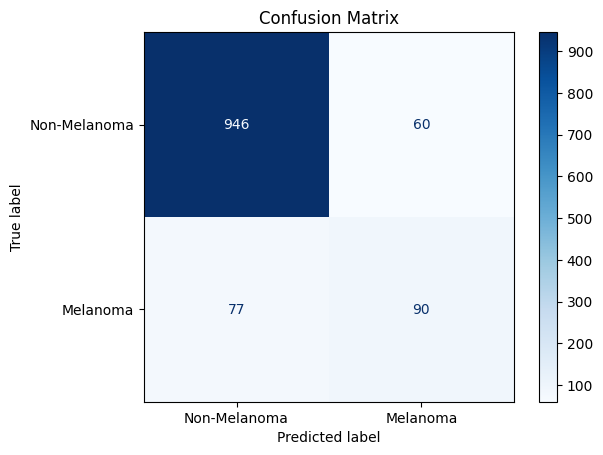

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Melanoma", "Melanoma"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()